---
## This script will create Supplemental Fig's (4 - 5) drafts. I'm using 3˚ latitude bins.
##### 2/13/26
---

In [1]:
# kernel: pangeo23

In [2]:
# imports
import os
import xarray as xr
import numpy as np
import netCDF4 
import glob
import pandas as pd
import geopandas as gpd
from datetime import datetime
from scipy import stats

from coastal_analysis_fns import *

/opt/sw/anaconda3/2023.09/envs/pangeo23/lib/python3.11/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


In [3]:
# interactive plotting stuff 
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib import rcParams
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.lines import Line2D 

#import matplotlib.dates as mdates
%matplotlib inline
plt.rcParams['figure.figsize'] = 12, 6
#%config InlineBackend.figure_format = 'retina'

import cartopy
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
def convert_dat_to_pctile(da):
    '''
    8/18/25
    
    Params:
    - da (DataArray) dims = staid, time
    
    returns:
    - pctile_da_out (xr.dataArray) same dims, data = transformed to percentile, within each station & day of year. 
    '''
    
    # np.arrays for raw data and output percentile-d data.
    dat = da.data
    pctile_dat = np.zeros(shape=dat.shape) * np.nan
    
    # for each day of the year, transform each station's data into percentile relative to that day-of-yr
    for d in range(1, 367):

        # mask to select day of year
        dayofyear_mask = (da.time.dt.dayofyear==d)
        ndays = np.sum(dayofyear_mask).item()

        # compute percentile value for each entry
        h22 = stats.rankdata(dat[:, dayofyear_mask], axis=1)
        h22_pct = (h22/ndays) * 100 # converting rank to percentile

        # save that day-of-year's percentile data
        pctile_dat[:, dayofyear_mask] = h22_pct
        
    # return
    pctile_da_out = xr.DataArray(pctile_dat, dims=da.dims, coords=da.coords)
    
    return pctile_da_out

In [6]:
# for each value in the 'valid' (dayofyearmask), I need to compare that value to all the pooled values in the dayofyearmask11,
# But I want to EXCLUDE the date itself from being assigned. 

In [7]:
def make_lagged_onsetmask1D(dat, lag):
    '''
    This function takes the mhw_onsets array/mask and returns one shifted over "lag" number of days
    
    params:
        dat (np.array or xr.dataArray) the mask you want to shift
        lag (int) the number of days/spaces you want to shift. negative = backwards/before, positive=forwards/after
        
    returns: lag_arr
    
    10/14/25 - adapted for 1-dimensional input data
    '''
    
    
    # empty array
    lag_arr = np.zeros(shape=dat.shape).astype(bool)
    abslag = abs(lag)

    # if a negative lag (aka before event onset)
    if lag < 0:

        lag_arr[:lag] = dat[abslag:]

    elif lag > 0:

        lag_arr[lag:] = dat[:(-lag)]
        
    elif lag==0:
        
        lag_arr = dat # self-explanatory?
        
    return lag_arr

In [8]:
def make_lagged_onsetmask(dat, lag):
    '''
    This function takes the mhw_onsets array/mask and returns one shifted over "lag" number of days
    
    params:
        dat (np.array or xr.dataArray) the mask you want to shift
        lag (int) the number of days/spaces you want to shift. negative = backwards/before, positive=forwards/after
        
    returns: lag_arr
    
    1/30/25
    '''
    
    
    # empty array
    lag_arr = np.zeros(shape=dat.shape).astype(bool)
    abslag = abs(lag)

    # if a negative lag (aka before event onset)
    if lag < 0:

        lag_arr[:, :lag] = dat[:, abslag:]

    elif lag > 0:

        lag_arr[:, lag:] = dat[:, :(-lag)]
        
    elif lag==0:
        lag_arr = dat
        
    return lag_arr

def bin_lat_scatters(latbins, lats, dat):
    
    binned_means = []
    bin_midpoints = []
    bin_n_obs = []

    i = 0

    while i < len(latbins)-1:

        bot_bin = latbins[i]
        top_bin = latbins[i+1]

    #    print(bot_bin, top_bin)

        binmask = (lats >= bot_bin) * (lats < top_bin)

        binned_means.append(np.nanmean(dat[binmask]))
        bin_midpoints.append(((bot_bin+top_bin)/2))
        bin_n_obs.append(np.sum(binmask))

        i += 1
        
    return binned_means, bin_midpoints, bin_n_obs

def prep_global_binned_leadlags(da, event_onsets, window, latbins):

    '''
    Function-izing code from earlier work...
    
    This function creates binned/lagged dataArrays of a desired variable centered on desired events, binned by lat.
    
    Params:
    - da (xr.dataArray) the input variable. dims = [staid, time]
    - event_onsets (xr.dataArray) bool indices to the events of interest. dims = [staid, time]
    - window (int) number of days before and after event onset which you are interested in binning
    - latbins (np.array) latitude bins to use
    
    Returns:
    - var_bin_lag_da (xr.Da) variable, averaged across various lags and binned by lat. dims = [lat bin, event-day]
    
    '''

    # these will hold the MHW evolutions in a different form. shape = [lat bin, lag day]
    bin_lag_profile_arr = np.zeros(shape=((len(latbins)-1), ((window*2)+1)))

    # counter var
    i = 0

    # will take lags from -w days prior to mhw event thru +w days 
    for l in range(-window, (window+1)):

        # make a mask to select all days with lag=l rel. to mhw onsets
        if not l==0:
            lagmhwmask = make_lagged_onsetmask(dat=event_onsets, lag=l)
        elif l==0: 
            lagmhwmask = event_onsets

        # sel avg. <var> at every station at that <event> lag
        var_lag_means = da.where(lagmhwmask).mean(dim='time').to_numpy()

        # bin by lat
        var_lag_means_binned, bin_midpoints, bin_nobs = bin_lat_scatters(latbins=latbins, lats=gdf['LAT'].to_numpy(), dat=var_lag_means)

        # add to arrays
        bin_lag_profile_arr[:, i] = var_lag_means_binned

        i+=1

    # put into dataArray
    bin_lag_profile_da = xr.DataArray(bin_lag_profile_arr, dims=['lat bin', 'day'], coords={'lat bin':bin_midpoints, 'day':np.array(range(-window, (window+1)))})

    return bin_lag_profile_da                      

In [9]:
script = 'FigS4S5_draftFeb26.ipynb'

In [10]:
# dataframe with the stations we are using
df = pd.read_csv('/home/nsiegert/projects/coastal_sst/data/hadisd_stations_using_Expanded.csv')
df = df.drop(['Unnamed: 0'], axis=1)

# convert df into geodataframe for ease of plotting
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(x=df.LON, y=df.LAT))

In [11]:
# open geophysical data

# MHW
hw_ds = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.1.5deg.marineheatwaves_roll11.nc') # 11 DAY ROLLING!!!
mhw_mask = hw_ds.MHW
mhw_onset_mask = hw_ds.MHW_onsets.astype(bool)

# thw
thw_ds = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.1.5deg.heatwaves.nc')
thw_mask = thw_ds.THW
thw_onset_mask = thw_ds.THW_onsets.astype(bool)

# station var's
tx_det_da = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.tx.detrend_anom.roll11.nc').Tx # new file 11/21
tn_det_da = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.tn.detrend_anom.roll11.nc').Tn # new file 11/21
td_det_da = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.td.detrend_anom.roll11.nc').Td # new file 11/21
slp_det_da = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.slp.detrend_anom.roll11.nc').slp # new file 11/21
windspeed_det_da = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.windspeeds.detrend_anom.roll11.nc').windspeeds # new file 11/21

# tmean
tx_raw_da = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.tx.nc').Tx
tn_raw_da = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.tn.nc').Tn
tmean_da = (tx_raw_da + tn_raw_da) / 2

# raw dewpoint
td_raw_da = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.td.nc').Td

#  SST 
sst_da = xr.open_dataset('/dx02/data/nsiegert/oisst_station_cirleavg/ALLSTATIONS.1.5deg.daily.sst.1.9.2025.nc').sst.sel(time=slice('1990-01-01', '2023-12-31'))
sst_det_da = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.sst.detrend_anom.roll11.nc').sst.sel(time=slice('1990-01-01', '2023-12-31')) # new file 11/21

# open heatflux data (anomalies, over the stations)
slhf15 = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.1.5deg.slhf.detrend_anom.roll11.nc').slhf
sshf15 = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.1.5deg.sshf.detrend_anom.roll11.nc').sshf
ssr15 = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.1.5deg.ssr.detrend_anom.roll11.nc').ssr
str15 = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.1.5deg.str.detrend_anom.roll11.nc').str

# mixed layer depth
mld_da = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.mld.nc').mld
mld_pctile_da = convert_dat_to_pctile(mld_da)

# open heat fluxes over land as well
slhfSTA = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.OverStations.slhf.detrend_anom.roll11.nc').slhf
sshfSTA = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.OverStations.sshf.detrend_anom.roll11.nc').sshf
ssrSTA = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.OverStations.ssr.detrend_anom.roll11.nc').ssr
strSTA = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.OverStations.str.detrend_anom.roll11.nc').str

# season masks
szn_ds = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.warm_cold_seasons.nc')
warmszn_mask = szn_ds.warmszn_mask.astype(bool)
coldszn_mask = szn_ds.coldszn_mask.astype(bool)

# analysis

In [12]:
# gather concurrent event onsets
concurrent_ev_mask = (mhw_mask * thw_mask)

# onsets are days where there is no concurrent event (=0), and the next day = 1
concurrent_ev_onsetmaskPre = (concurrent_ev_mask==0).data[:, :-1] * concurrent_ev_mask.data[:, 1:] # and have to drop the last day of ds from analysis. This gets us an onset mask for the second day of the ds onwards. 
concurrent_ev_onsetmask = np.zeros(shape=concurrent_ev_mask.shape)
concurrent_ev_onsetmask[:, 1:] = concurrent_ev_onsetmaskPre # fill in the 0 on the first day0 (which can't be an onset b/c we don't know the status of the day prior)

concurrent_ev_onsetmask_da = xr.DataArray(concurrent_ev_onsetmask, dims=concurrent_ev_mask.dims, coords=concurrent_ev_mask.coords)

In [13]:
## warm-season lead-lags with ONE GLOBAL BIN, using standardized anomaly ##

In [14]:
# concurrent events onset mask
concurrent_ev_onsetmask.astype(bool)

# standalone events onset mask: = mhw_standalone_mask, thw_standalone_mask

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

In [15]:
### these take a very long time to run...

In [16]:
# lead-lags for warm-season MHW events
eventUse = xr.where((hw_ds.MHW_onsets*np.logical_not(thw_ds.THW)*warmszn_mask), True, False).data 
ww = 30
lbins = np.arange(-60, 71, 3)

sst_binlag_MHW_w = prep_global_binned_leadlags(da=sst_det_da, event_onsets=eventUse, window=ww, latbins=lbins)
tx_binlag_MHW_w = prep_global_binned_leadlags(da=tx_det_da, event_onsets=eventUse, window=ww, latbins=lbins)
td_binlag_MHW_w = prep_global_binned_leadlags(da=td_det_da, event_onsets=eventUse, window=ww, latbins=lbins)
slp_binlag_MHW_w = prep_global_binned_leadlags(da=slp_det_da, event_onsets=eventUse, window=ww, latbins=lbins)
windspeeds_binlag_MHW_w = prep_global_binned_leadlags(da=windspeed_det_da, event_onsets=eventUse, window=ww, latbins=lbins)

# heat flux...
slhf_binlag_MHW_w = prep_global_binned_leadlags(da=slhf15, event_onsets=eventUse, window=ww, latbins=lbins)
sshf_binlag_MHW_w = prep_global_binned_leadlags(da=sshf15, event_onsets=eventUse, window=ww, latbins=lbins)
ssr_binlag_MHW_w = prep_global_binned_leadlags(da=ssr15, event_onsets=eventUse, window=ww, latbins=lbins)
str_binlag_MHW_w = prep_global_binned_leadlags(da=str15, event_onsets=eventUse, window=ww, latbins=lbins)

# MLD... (need to trim the event selection)
eventUseTrim = xr.where((hw_ds.MHW_onsets*np.logical_not(thw_ds.THW)*warmszn_mask), True, False).sel(time=slice('1993-01-01', '2021-06-30'))
mld_pctile_da['time'] = eventUseTrim.time
eventUseTrimDat = eventUseTrim.data

MLDPctile_binlag_MHW_w = prep_global_binned_leadlags(da=mld_pctile_da, event_onsets=eventUseTrimDat, window=ww, latbins=lbins)

# lead-lags for warm-season Standalone THW events
eventUse = xr.where((thw_ds.THW_onsets*np.logical_not(hw_ds.MHW)*warmszn_mask), True, False).data 
ww = 30
lbins = np.arange(-60, 71, 3)

sst_binlag_THW_w = prep_global_binned_leadlags(da=sst_det_da, event_onsets=eventUse, window=ww, latbins=lbins)
tx_binlag_THW_w = prep_global_binned_leadlags(da=tx_det_da, event_onsets=eventUse, window=ww, latbins=lbins)
td_binlag_THW_w = prep_global_binned_leadlags(da=td_det_da, event_onsets=eventUse, window=ww, latbins=lbins)
slp_binlag_THW_w = prep_global_binned_leadlags(da=slp_det_da, event_onsets=eventUse, window=ww, latbins=lbins)
windspeeds_binlag_THW_w = prep_global_binned_leadlags(da=windspeed_det_da, event_onsets=eventUse, window=ww, latbins=lbins)

# heat flux...
slhf_binlag_THW_w = prep_global_binned_leadlags(da=slhf15, event_onsets=eventUse, window=ww, latbins=lbins)
sshf_binlag_THW_w = prep_global_binned_leadlags(da=sshf15, event_onsets=eventUse, window=ww, latbins=lbins)
ssr_binlag_THW_w = prep_global_binned_leadlags(da=ssr15, event_onsets=eventUse, window=ww, latbins=lbins)
str_binlag_THW_w = prep_global_binned_leadlags(da=str15, event_onsets=eventUse, window=ww, latbins=lbins)

# MLD... (need to trim the event selection)
eventUseTrim = xr.where((thw_ds.THW_onsets*np.logical_not(hw_ds.MHW)*warmszn_mask), True, False).sel(time=slice('1993-01-01', '2021-06-30'))
mld_pctile_da['time'] = eventUseTrim.time
eventUseTrimDat = eventUseTrim.data

MLDPctile_binlag_THW_w = prep_global_binned_leadlags(da=mld_pctile_da, event_onsets=eventUseTrimDat, window=ww, latbins=lbins)

# lead-lags for warm-season concurrent events
eventUse = xr.where((concurrent_ev_onsetmask_da*warmszn_mask), True, False).data 
ww = 30
lbins = np.arange(-60, 71, 3)

sst_binlag_con_w = prep_global_binned_leadlags(da=sst_det_da, event_onsets=eventUse, window=ww, latbins=lbins)
tx_binlag_con_w = prep_global_binned_leadlags(da=tx_det_da, event_onsets=eventUse, window=ww, latbins=lbins)
td_binlag_con_w = prep_global_binned_leadlags(da=td_det_da, event_onsets=eventUse, window=ww, latbins=lbins)
slp_binlag_con_w = prep_global_binned_leadlags(da=slp_det_da, event_onsets=eventUse, window=ww, latbins=lbins)
windspeeds_binlag_con_w = prep_global_binned_leadlags(da=windspeed_det_da, event_onsets=eventUse, window=ww, latbins=lbins)

# heat flux...
slhf_binlag_con_w = prep_global_binned_leadlags(da=slhf15, event_onsets=eventUse, window=ww, latbins=lbins)
sshf_binlag_con_w = prep_global_binned_leadlags(da=sshf15, event_onsets=eventUse, window=ww, latbins=lbins)
ssr_binlag_con_w = prep_global_binned_leadlags(da=ssr15, event_onsets=eventUse, window=ww, latbins=lbins)
str_binlag_con_w = prep_global_binned_leadlags(da=str15, event_onsets=eventUse, window=ww, latbins=lbins)

# MLD... (need to trim the event selection)
eventUseTrim = xr.where((concurrent_ev_onsetmask_da*warmszn_mask), True, False).sel(time=slice('1993-01-01', '2021-06-30'))
mld_pctile_da['time'] = eventUseTrim.time
eventUseTrimDat = eventUseTrim.data

MLDPctile_binlag_con_w = prep_global_binned_leadlags(da=mld_pctile_da, event_onsets=eventUseTrimDat, window=ww, latbins=lbins)

In [17]:
# lead-lags for cold-season MHW events
eventUse = xr.where((hw_ds.MHW_onsets*np.logical_not(thw_ds.THW)*coldszn_mask), True, False).data 
ww = 30
lbins = np.arange(-60, 71, 3)

sst_binlag_MHW_c = prep_global_binned_leadlags(da=sst_det_da, event_onsets=eventUse, window=ww, latbins=lbins)
tx_binlag_MHW_c = prep_global_binned_leadlags(da=tx_det_da, event_onsets=eventUse, window=ww, latbins=lbins)
td_binlag_MHW_c = prep_global_binned_leadlags(da=td_det_da, event_onsets=eventUse, window=ww, latbins=lbins)
slp_binlag_MHW_c = prep_global_binned_leadlags(da=slp_det_da, event_onsets=eventUse, window=ww, latbins=lbins)
windspeeds_binlag_MHW_c = prep_global_binned_leadlags(da=windspeed_det_da, event_onsets=eventUse, window=ww, latbins=lbins)

# heat flux...
slhf_binlag_MHW_c = prep_global_binned_leadlags(da=slhf15, event_onsets=eventUse, window=ww, latbins=lbins)
sshf_binlag_MHW_c = prep_global_binned_leadlags(da=sshf15, event_onsets=eventUse, window=ww, latbins=lbins)
ssr_binlag_MHW_c = prep_global_binned_leadlags(da=ssr15, event_onsets=eventUse, window=ww, latbins=lbins)
str_binlag_MHW_c = prep_global_binned_leadlags(da=str15, event_onsets=eventUse, window=ww, latbins=lbins)

# MLD... (need to trim the event selection)
eventUseTrim = xr.where((hw_ds.MHW_onsets*np.logical_not(thw_ds.THW)*coldszn_mask), True, False).sel(time=slice('1993-01-01', '2021-06-30'))
mld_pctile_da['time'] = eventUseTrim.time
eventUseTrimDat = eventUseTrim.data

MLDPctile_binlag_MHW_c = prep_global_binned_leadlags(da=mld_pctile_da, event_onsets=eventUseTrimDat, window=ww, latbins=lbins)

# lead-lags for warm-season Standalone THW events
eventUse = xr.where((thw_ds.THW_onsets*np.logical_not(hw_ds.MHW)*coldszn_mask), True, False).data 
ww = 30
lbins = np.arange(-60, 71, 3)

sst_binlag_THW_c = prep_global_binned_leadlags(da=sst_det_da, event_onsets=eventUse, window=ww, latbins=lbins)
tx_binlag_THW_c = prep_global_binned_leadlags(da=tx_det_da, event_onsets=eventUse, window=ww, latbins=lbins)
td_binlag_THW_c = prep_global_binned_leadlags(da=td_det_da, event_onsets=eventUse, window=ww, latbins=lbins)
slp_binlag_THW_c = prep_global_binned_leadlags(da=slp_det_da, event_onsets=eventUse, window=ww, latbins=lbins)
windspeeds_binlag_THW_c = prep_global_binned_leadlags(da=windspeed_det_da, event_onsets=eventUse, window=ww, latbins=lbins)

# heat flux...
slhf_binlag_THW_c = prep_global_binned_leadlags(da=slhf15, event_onsets=eventUse, window=ww, latbins=lbins)
sshf_binlag_THW_c = prep_global_binned_leadlags(da=sshf15, event_onsets=eventUse, window=ww, latbins=lbins)
ssr_binlag_THW_c = prep_global_binned_leadlags(da=ssr15, event_onsets=eventUse, window=ww, latbins=lbins)
str_binlag_THW_c = prep_global_binned_leadlags(da=str15, event_onsets=eventUse, window=ww, latbins=lbins)

# MLD... (need to trim the event selection)
eventUseTrim = xr.where((thw_ds.THW_onsets*np.logical_not(hw_ds.MHW)*coldszn_mask), True, False).sel(time=slice('1993-01-01', '2021-06-30'))
mld_pctile_da['time'] = eventUseTrim.time
eventUseTrimDat = eventUseTrim.data

MLDPctile_binlag_THW_c = prep_global_binned_leadlags(da=mld_pctile_da, event_onsets=eventUseTrimDat, window=ww, latbins=lbins)

# lead-lags for warm-season concurrent events
eventUse = xr.where((concurrent_ev_onsetmask_da*coldszn_mask), True, False).data 
ww = 30
lbins = np.arange(-60, 71, 3)

sst_binlag_con_c = prep_global_binned_leadlags(da=sst_det_da, event_onsets=eventUse, window=ww, latbins=lbins)
tx_binlag_con_c = prep_global_binned_leadlags(da=tx_det_da, event_onsets=eventUse, window=ww, latbins=lbins)
td_binlag_con_c = prep_global_binned_leadlags(da=td_det_da, event_onsets=eventUse, window=ww, latbins=lbins)
slp_binlag_con_c = prep_global_binned_leadlags(da=slp_det_da, event_onsets=eventUse, window=ww, latbins=lbins)
windspeeds_binlag_con_c = prep_global_binned_leadlags(da=windspeed_det_da, event_onsets=eventUse, window=ww, latbins=lbins)

# heat flux...
slhf_binlag_con_c = prep_global_binned_leadlags(da=slhf15, event_onsets=eventUse, window=ww, latbins=lbins)
sshf_binlag_con_c = prep_global_binned_leadlags(da=sshf15, event_onsets=eventUse, window=ww, latbins=lbins)
ssr_binlag_con_c = prep_global_binned_leadlags(da=ssr15, event_onsets=eventUse, window=ww, latbins=lbins)
str_binlag_con_c = prep_global_binned_leadlags(da=str15, event_onsets=eventUse, window=ww, latbins=lbins)

# MLD... (need to trim the event selection)
eventUseTrim = xr.where((concurrent_ev_onsetmask_da*coldszn_mask), True, False).sel(time=slice('1993-01-01', '2021-06-30'))
mld_pctile_da['time'] = eventUseTrim.time
eventUseTrimDat = eventUseTrim.data

MLDPctile_binlag_con_c = prep_global_binned_leadlags(da=mld_pctile_da, event_onsets=eventUseTrimDat, window=ww, latbins=lbins)

In [18]:
print('DONE')

DONE


## Plot

In [19]:
# generate list of letters to label each subplot
import string

ltrs = list(string.ascii_lowercase)

ltrs_plus_a = []
ltrs_plus_b = []

for ll in ltrs: 
    
    ltrs_plus_a.append('a'+ll)
    ltrs_plus_b.append('b'+ll)
    
letters_list = ltrs + ltrs_plus_a + ltrs_plus_b

In [20]:
# set cmap for tx
vmin = 0
vmax = 3
ncol_tx = 11
bounds_tx = np.linspace(vmin, vmax, ncol_tx)
cols = plt.get_cmap('Reds')(np.linspace(0,1,len(bounds_tx)+1))
cmap_tx = colors.ListedColormap(cols[1:-1])
cmap_tx.set_over(cols[-1])
cmap_tx.set_under('lightblue')
norm_tx = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# set cmap for sst
vmin = 0
vmax = 2
ncol_s = 11
bounds_s = np.linspace(vmin, vmax, ncol_s)
cols = plt.get_cmap('Reds')(np.linspace(0,1,len(bounds_s)+1))
cmap_s = colors.ListedColormap(cols[1:-1])
cmap_s.set_over(cols[-1])
cmap_s.set_under('lightblue')
norm_s = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# set cmap for slp
vmin = -4
vmax = 4
ncol_sl = 11
bounds_sl = np.linspace(vmin, vmax, ncol_sl)
cols = plt.get_cmap('RdBu_r')(np.linspace(0,1,len(bounds_sl)+1))
cmap_sl = colors.ListedColormap(cols[1:-1])
cmap_sl.set_over(cols[-1])
cmap_sl.set_under(cols[0])
norm_sl= mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# set cmap for wind
vmin = -1
vmax = 1
ncol_w = 11
bounds_w = np.linspace(vmin, vmax, ncol_w)
cols = plt.get_cmap('RdBu_r')(np.linspace(0,1,len(bounds_w)+1))
cmap_w = colors.ListedColormap(cols[1:-1])
cmap_w.set_over(cols[-1])
cmap_w.set_under(cols[0])
norm_w= mpl.colors.Normalize(vmin=vmin, vmax=vmax)

In [21]:
# heat flux cmap
vmin = -50
vmax = 50
ncol = 11
bounds = np.linspace(vmin, vmax, ncol)
cols = plt.get_cmap('RdBu_r')(np.linspace(0,1,len(bounds)+1))
cmap = colors.ListedColormap(cols[1:-1])
cmap.set_over(cols[-1])
cmap.set_under(cols[0])
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

cmap_hf, norm_hf, bounds_hf = (cmap, norm, bounds)

In [22]:
# pctile (MLD) cmap
vmin = 25
vmax = 75
ncol = 11
bounds = np.linspace(vmin, vmax, ncol)
cols = plt.get_cmap('RdBu_r')(np.linspace(0,1,len(bounds)+1))
cmap = colors.ListedColormap(cols[1:-1])
cmap.set_over(cols[-1])
cmap.set_under(cols[0])
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

cmap_mld, norm_mld, bounds_mld = (cmap, norm, bounds)

In [23]:
print('Done')

Done


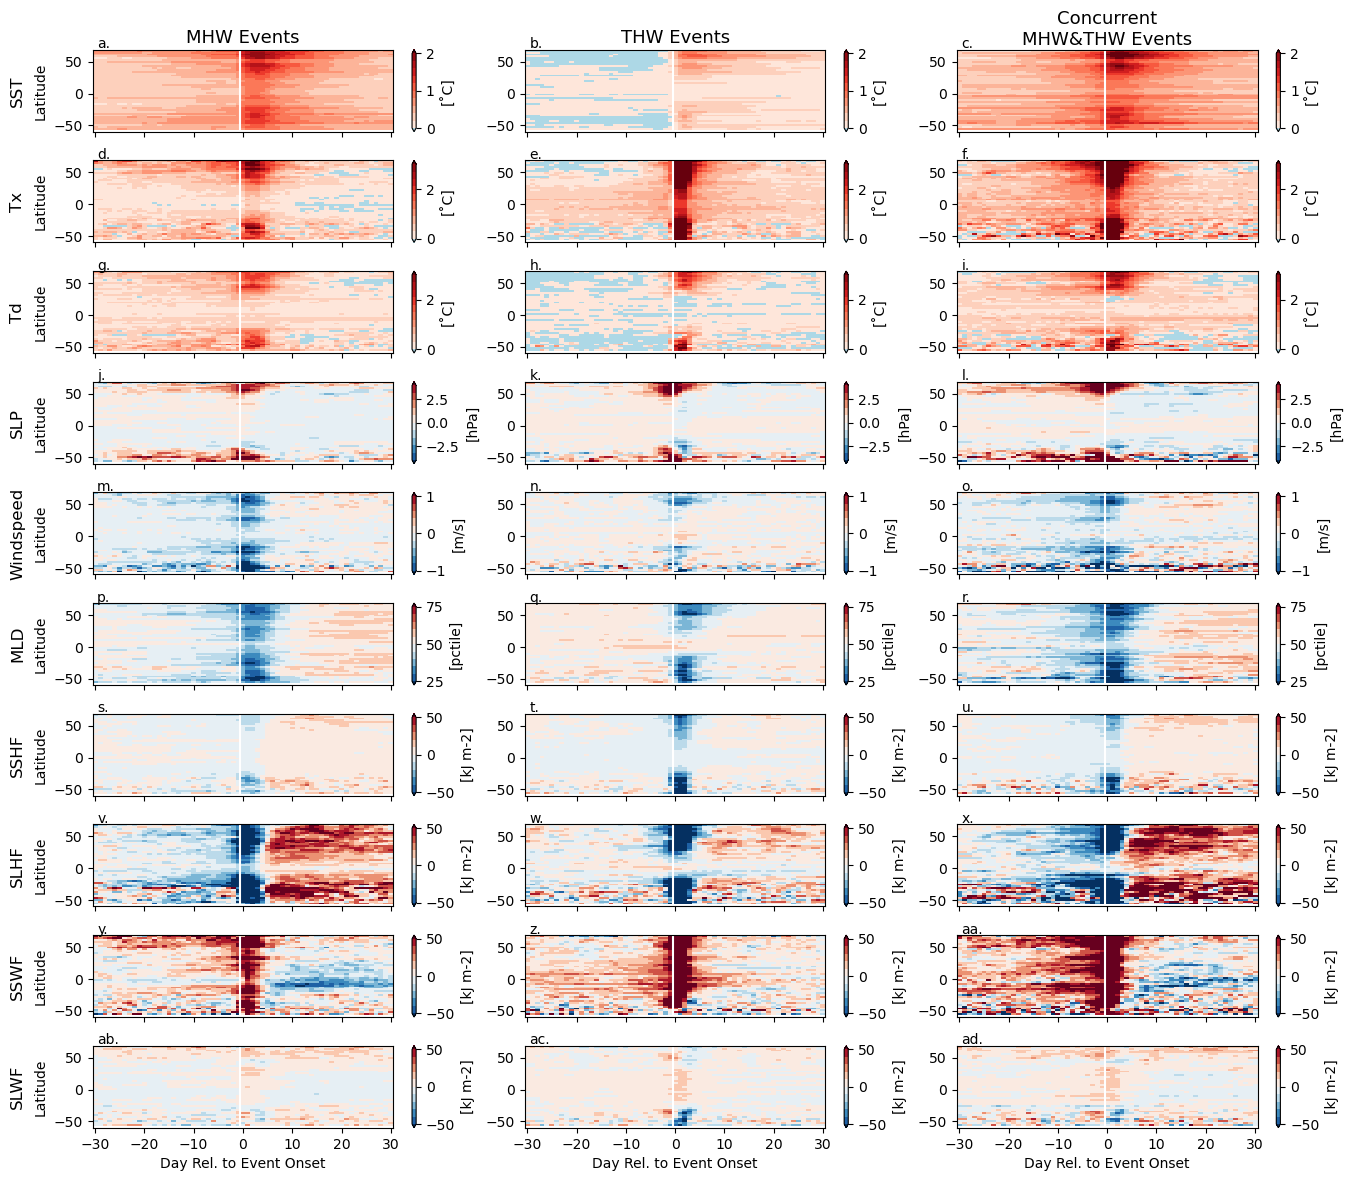

In [25]:
## WARM SEASON LEAD-LAGS (S4) -- Going to save this one

# set up figure
nrows = 10
ncols = 3
fig = plt.figure(figsize=(16, 14))
gs = gridspec.GridSpec(nrows=nrows, ncols=ncols, figure=fig) 
gs.update(wspace=0.15, hspace=0.35)


to_plot_list = [[sst_binlag_MHW_w, sst_binlag_THW_w, sst_binlag_con_w],
                [tx_binlag_MHW_w , tx_binlag_THW_w, tx_binlag_con_w],
                [td_binlag_MHW_w, td_binlag_THW_w, td_binlag_con_w],
                [slp_binlag_MHW_w, slp_binlag_THW_w, slp_binlag_con_w],
                [windspeeds_binlag_MHW_w, windspeeds_binlag_THW_w, windspeeds_binlag_con_w], 
                [MLDPctile_binlag_MHW_w, MLDPctile_binlag_THW_w, MLDPctile_binlag_con_w],
                [sshf_binlag_MHW_w, sshf_binlag_THW_w, sshf_binlag_con_w], 
                [slhf_binlag_MHW_w, slhf_binlag_THW_w, slhf_binlag_con_w],
                [ssr_binlag_MHW_w, ssr_binlag_THW_w, ssr_binlag_con_w],
                [str_binlag_MHW_w, str_binlag_THW_w, str_binlag_con_w]]

cmap_list = [cmap_s, cmap_tx, cmap_tx, cmap_sl, cmap_w, cmap_mld, cmap_hf, cmap_hf, cmap_hf, cmap_hf]
norm_list = [norm_s, norm_tx, norm_tx, norm_sl, norm_w, norm_mld, norm_hf, norm_hf, norm_hf, norm_hf]
bounds_list = [bounds_s, bounds_tx, bounds_tx, bounds_sl, bounds_w, bounds_mld, bounds_hf, bounds_hf, bounds_hf, bounds_hf]
cmap_label_list = ['[˚C]', '[˚C]', '[˚C]', '[hPa]', '[m/s]', '[pctile]', '[kJ m-2]', '[kJ m-2]', '[kJ m-2]', '[kJ m-2]']
row_label_list = ['SST', 'Tx', 'Td', 'SLP', 'Windspeed', 'MLD', 'SSHF', 'SLHF', 'SSWF', 'SLWF']

axes = []

pltctr = 0
for r in range(nrows):
    for c in range(ncols):
        
        ax = fig.add_subplot(gs[r, c])

        
        data2plot = to_plot_list[r][c]
        data2plot.plot(ax=ax, cmap=cmap_list[r], norm=norm_list[r], cbar_kwargs={'label':cmap_label_list[r], 'extend':'both'})
        
        ax.axvline(-0.5, color='white')
        ax.set(title='', xlabel='', ylabel='')
        
        if not r==(nrows-1):
            ax.set_xticks([-30., -20., -10.,   0.,  10.,  20.,  30.], labels='')
        else:
            ax.set_xticks([-30., -20., -10.,   0.,  10.,  20.,  30.])
            ax.set(xlabel='Day Rel. to Event Onset')
            
        if c==0:
            ax.set(ylabel='Latitude')
            
        ax.text(s='{}.'.format(letters_list[pltctr]), x=0.015, y=1.02, transform=ax.transAxes, ha='left', fontsize=10)
            
        axes.append(ax)
        pltctr+=1 
            
# subplot labels
axes[0].text(x=0.5, y=1.15, s='MHW Events', va='center', ha='center', fontsize='13',
    transform=axes[0].transAxes)

axes[1].text(x=0.5, y=1.15, s='THW Events', va='center', ha='center', fontsize='13',
    transform=axes[1].transAxes)

axes[2].text(x=0.5, y=1.25, s='Concurrent\nMHW&THW Events', va='center', ha='center', fontsize='13',
    transform=axes[2].transAxes)

# y labels
for r in range(nrows):
    aa = axes[0+(r*3)]
    aa.text(x=-0.25, y=0.50, s=row_label_list[r], va='center', ha='center',
        rotation='vertical', rotation_mode='anchor', fontsize='12',
        transform=aa.transAxes)
    
    
# SAVE FIGURE
plt.savefig('/home/nsiegert/projects/coastal_sst/plots/grl_submission_2.2026/FigS4_coastalsst_grl_2_26.png', format='png', bbox_inches='tight')

plt.show()

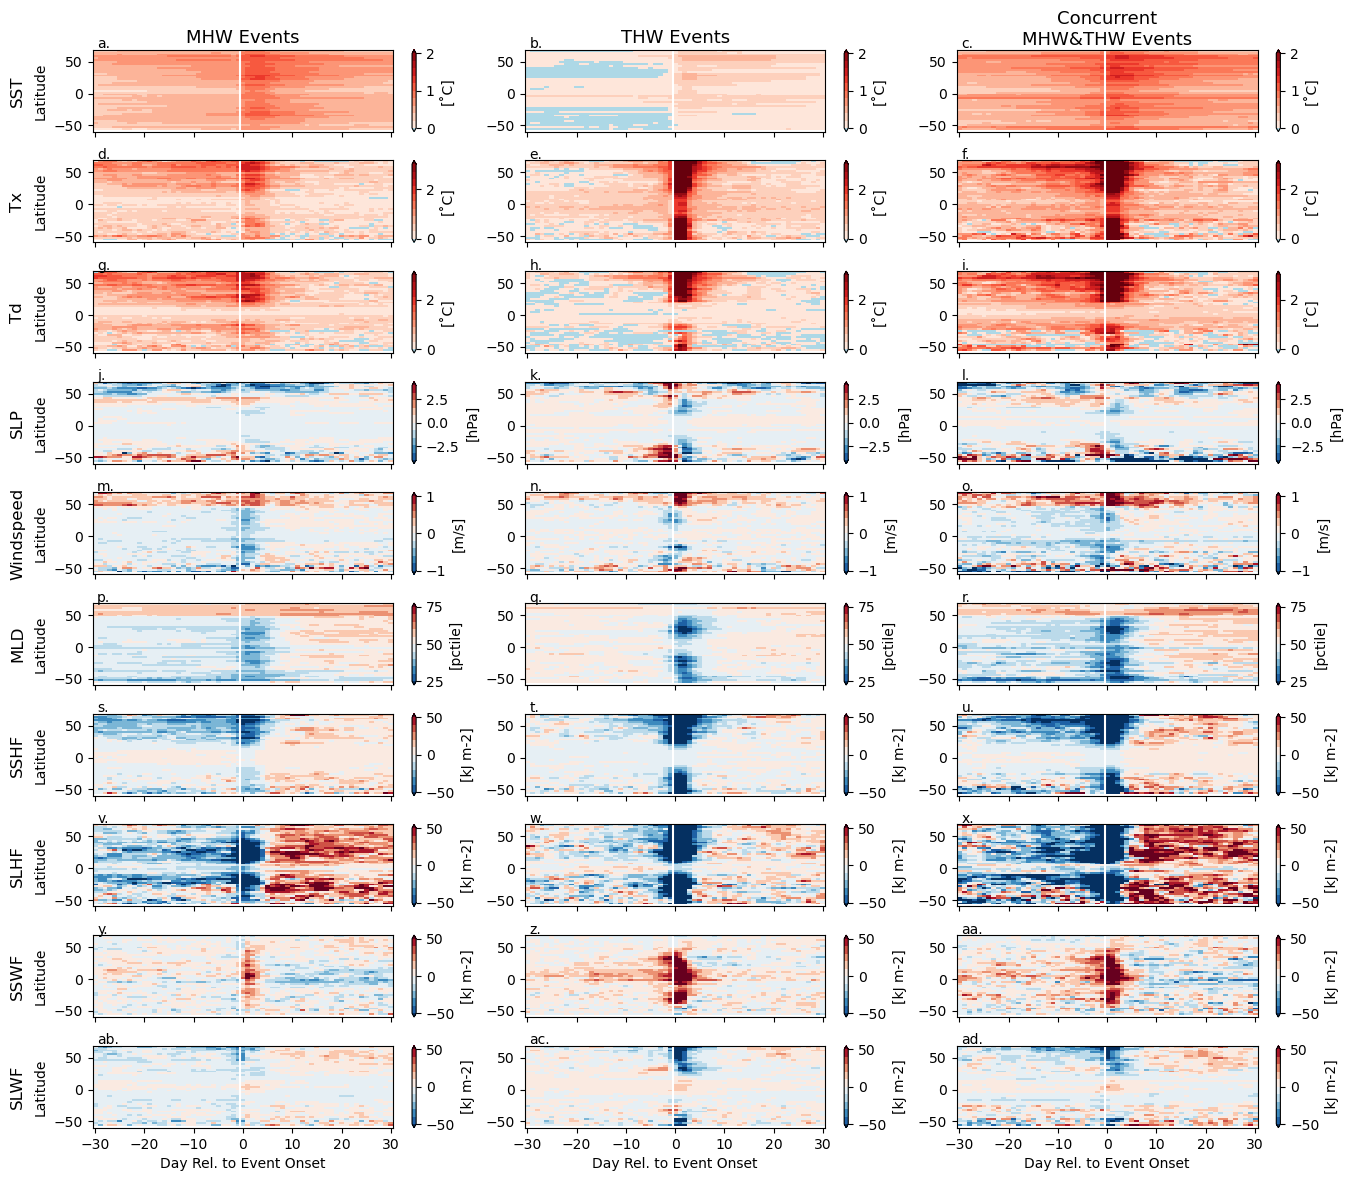

In [27]:
## COLD SEASON LEAD-LAGS (S5) -- saving this one

# set up figure
nrows = 10
ncols = 3
fig = plt.figure(figsize=(16, 14))
gs = gridspec.GridSpec(nrows=nrows, ncols=ncols, figure=fig) 
gs.update(wspace=0.15, hspace=0.35)


to_plot_list = [[sst_binlag_MHW_c, sst_binlag_THW_c, sst_binlag_con_c],
                [tx_binlag_MHW_c, tx_binlag_THW_c, tx_binlag_con_c],
                [td_binlag_MHW_c, td_binlag_THW_c, td_binlag_con_c],
                [slp_binlag_MHW_c, slp_binlag_THW_c, slp_binlag_con_c],
                [windspeeds_binlag_MHW_c, windspeeds_binlag_THW_c, windspeeds_binlag_con_c], 
                [MLDPctile_binlag_MHW_c, MLDPctile_binlag_THW_c, MLDPctile_binlag_con_c],
                [sshf_binlag_MHW_c, sshf_binlag_THW_c, sshf_binlag_con_c], 
                [slhf_binlag_MHW_c, slhf_binlag_THW_c, slhf_binlag_con_c],
                [ssr_binlag_MHW_c, ssr_binlag_THW_c, ssr_binlag_con_c],
                [str_binlag_MHW_c, str_binlag_THW_c, str_binlag_con_c]]

cmap_list = [cmap_s, cmap_tx, cmap_tx, cmap_sl, cmap_w, cmap_mld, cmap_hf, cmap_hf, cmap_hf, cmap_hf]
norm_list = [norm_s, norm_tx, norm_tx, norm_sl, norm_w, norm_mld, norm_hf, norm_hf, norm_hf, norm_hf]
bounds_list = [bounds_s, bounds_tx, bounds_tx, bounds_sl, bounds_w, bounds_mld, bounds_hf, bounds_hf, bounds_hf, bounds_hf]
cmap_label_list = ['[˚C]', '[˚C]', '[˚C]', '[hPa]', '[m/s]', '[pctile]', '[kJ m-2]', '[kJ m-2]', '[kJ m-2]', '[kJ m-2]']
row_label_list = ['SST', 'Tx', 'Td', 'SLP', 'Windspeed', 'MLD', 'SSHF', 'SLHF', 'SSWF', 'SLWF']

axes = []

pltctr = 0
for r in range(nrows):
    for c in range(ncols):
        
        ax = fig.add_subplot(gs[r, c])

        
        data2plot = to_plot_list[r][c]
        data2plot.plot(ax=ax, cmap=cmap_list[r], norm=norm_list[r], cbar_kwargs={'label':cmap_label_list[r], 'extend':'both'})
        
        ax.axvline(-0.5, color='white')
        ax.set(title='', xlabel='', ylabel='')
        
        if not r==(nrows-1):
            ax.set_xticks([-30., -20., -10.,   0.,  10.,  20.,  30.], labels='')
        else:
            ax.set_xticks([-30., -20., -10.,   0.,  10.,  20.,  30.])
            ax.set(xlabel='Day Rel. to Event Onset')
            
        if c==0:
            ax.set(ylabel='Latitude')
            
        ax.text(s='{}.'.format(letters_list[pltctr]), x=0.015, y=1.02, transform=ax.transAxes, ha='left', fontsize=10)
            
        axes.append(ax)
        pltctr+=1 

            
# subplot labels
axes[0].text(x=0.5, y=1.15, s='MHW Events', va='center', ha='center', fontsize='13',
    transform=axes[0].transAxes)

axes[1].text(x=0.5, y=1.15, s='THW Events', va='center', ha='center', fontsize='13',
    transform=axes[1].transAxes)

axes[2].text(x=0.5, y=1.25, s='Concurrent\nMHW&THW Events', va='center', ha='center', fontsize='13',
    transform=axes[2].transAxes)

# y labels
for r in range(nrows):
    aa = axes[0+(r*3)]
    aa.text(x=-0.25, y=0.50, s=row_label_list[r], va='center', ha='center',
        rotation='vertical', rotation_mode='anchor', fontsize='12',
        transform=aa.transAxes)
    
# SAVE FIGURE
plt.savefig('/home/nsiegert/projects/coastal_sst/plots/grl_submission_2.2026/FigS5_coastalsst_grl_2_26.png', format='png', bbox_inches='tight')

plt.show()

### add over-station heat fluxes as well...

In [28]:
# lead-lags for warm-season MHW events
eventUse = xr.where((hw_ds.MHW_onsets*np.logical_not(thw_ds.THW)*warmszn_mask), True, False).data 
ww = 30
lbins = np.arange(-60, 71, 3)

slhfSTA_binlag_MHW_w = prep_global_binned_leadlags(da=slhfSTA, event_onsets=eventUse, window=ww, latbins=lbins)
sshfSTA_binlag_MHW_w = prep_global_binned_leadlags(da=sshfSTA, event_onsets=eventUse, window=ww, latbins=lbins)
ssrSTA_binlag_MHW_w = prep_global_binned_leadlags(da=ssrSTA, event_onsets=eventUse, window=ww, latbins=lbins)
strSTA_binlag_MHW_w = prep_global_binned_leadlags(da=strSTA, event_onsets=eventUse, window=ww, latbins=lbins)

# lead-lags for warm-season Standalone THW events
eventUse = xr.where((thw_ds.THW_onsets*np.logical_not(hw_ds.MHW)*warmszn_mask), True, False).data 
ww = 30
lbins = np.arange(-60, 71, 3)

slhfSTA_binlag_THW_w = prep_global_binned_leadlags(da=slhfSTA, event_onsets=eventUse, window=ww, latbins=lbins)
sshfSTA_binlag_THW_w = prep_global_binned_leadlags(da=sshfSTA, event_onsets=eventUse, window=ww, latbins=lbins)
ssrSTA_binlag_THW_w = prep_global_binned_leadlags(da=ssrSTA, event_onsets=eventUse, window=ww, latbins=lbins)

In [29]:
strSTA_binlag_THW_w = prep_global_binned_leadlags(da=strSTA, event_onsets=eventUse, window=ww, latbins=lbins)

# lead-lags for warm-season concurrent events
eventUse = xr.where((concurrent_ev_onsetmask_da*warmszn_mask), True, False).data 
ww = 30
lbins = np.arange(-60, 71, 3)

slhfSTA_binlag_con_w = prep_global_binned_leadlags(da=slhfSTA, event_onsets=eventUse, window=ww, latbins=lbins)
sshfSTA_binlag_con_w = prep_global_binned_leadlags(da=sshfSTA, event_onsets=eventUse, window=ww, latbins=lbins)
ssrSTA_binlag_con_w = prep_global_binned_leadlags(da=ssrSTA, event_onsets=eventUse, window=ww, latbins=lbins)
strSTA_binlag_con_w = prep_global_binned_leadlags(da=strSTA, event_onsets=eventUse, window=ww, latbins=lbins)

In [30]:
# lead-lags for cold-season MHW events
eventUse = xr.where((hw_ds.MHW_onsets*np.logical_not(thw_ds.THW)*coldszn_mask), True, False).data 
ww = 30
lbins = np.arange(-60, 71, 3)

slhfSTA_binlag_MHW_c = prep_global_binned_leadlags(da=slhfSTA, event_onsets=eventUse, window=ww, latbins=lbins)
sshfSTA_binlag_MHW_c = prep_global_binned_leadlags(da=sshfSTA, event_onsets=eventUse, window=ww, latbins=lbins)
ssrSTA_binlag_MHW_c = prep_global_binned_leadlags(da=ssrSTA, event_onsets=eventUse, window=ww, latbins=lbins)
strSTA_binlag_MHW_c = prep_global_binned_leadlags(da=strSTA, event_onsets=eventUse, window=ww, latbins=lbins)

# lead-lags for warm-season Standalone THW events
eventUse = xr.where((thw_ds.THW_onsets*np.logical_not(hw_ds.MHW)*coldszn_mask), True, False).data 
ww = 30
lbins = np.arange(-60, 71, 3)

slhfSTA_binlag_THW_c = prep_global_binned_leadlags(da=slhfSTA, event_onsets=eventUse, window=ww, latbins=lbins)
sshfSTA_binlag_THW_c = prep_global_binned_leadlags(da=sshfSTA, event_onsets=eventUse, window=ww, latbins=lbins)
ssrSTA_binlag_THW_c = prep_global_binned_leadlags(da=ssrSTA, event_onsets=eventUse, window=ww, latbins=lbins)
strSTA_binlag_THW_c = prep_global_binned_leadlags(da=strSTA, event_onsets=eventUse, window=ww, latbins=lbins)

# lead-lags for warm-season concurrent events
eventUse = xr.where((concurrent_ev_onsetmask_da*coldszn_mask), True, False).data 
ww = 30
lbins = np.arange(-60, 71, 3)

slhfSTA_binlag_con_c = prep_global_binned_leadlags(da=slhfSTA, event_onsets=eventUse, window=ww, latbins=lbins)
sshfSTA_binlag_con_c = prep_global_binned_leadlags(da=sshfSTA, event_onsets=eventUse, window=ww, latbins=lbins)
ssrSTA_binlag_con_c = prep_global_binned_leadlags(da=ssrSTA, event_onsets=eventUse, window=ww, latbins=lbins)
strSTA_binlag_con_c = prep_global_binned_leadlags(da=strSTA, event_onsets=eventUse, window=ww, latbins=lbins)

In [31]:
print('DONE111')

DONE111


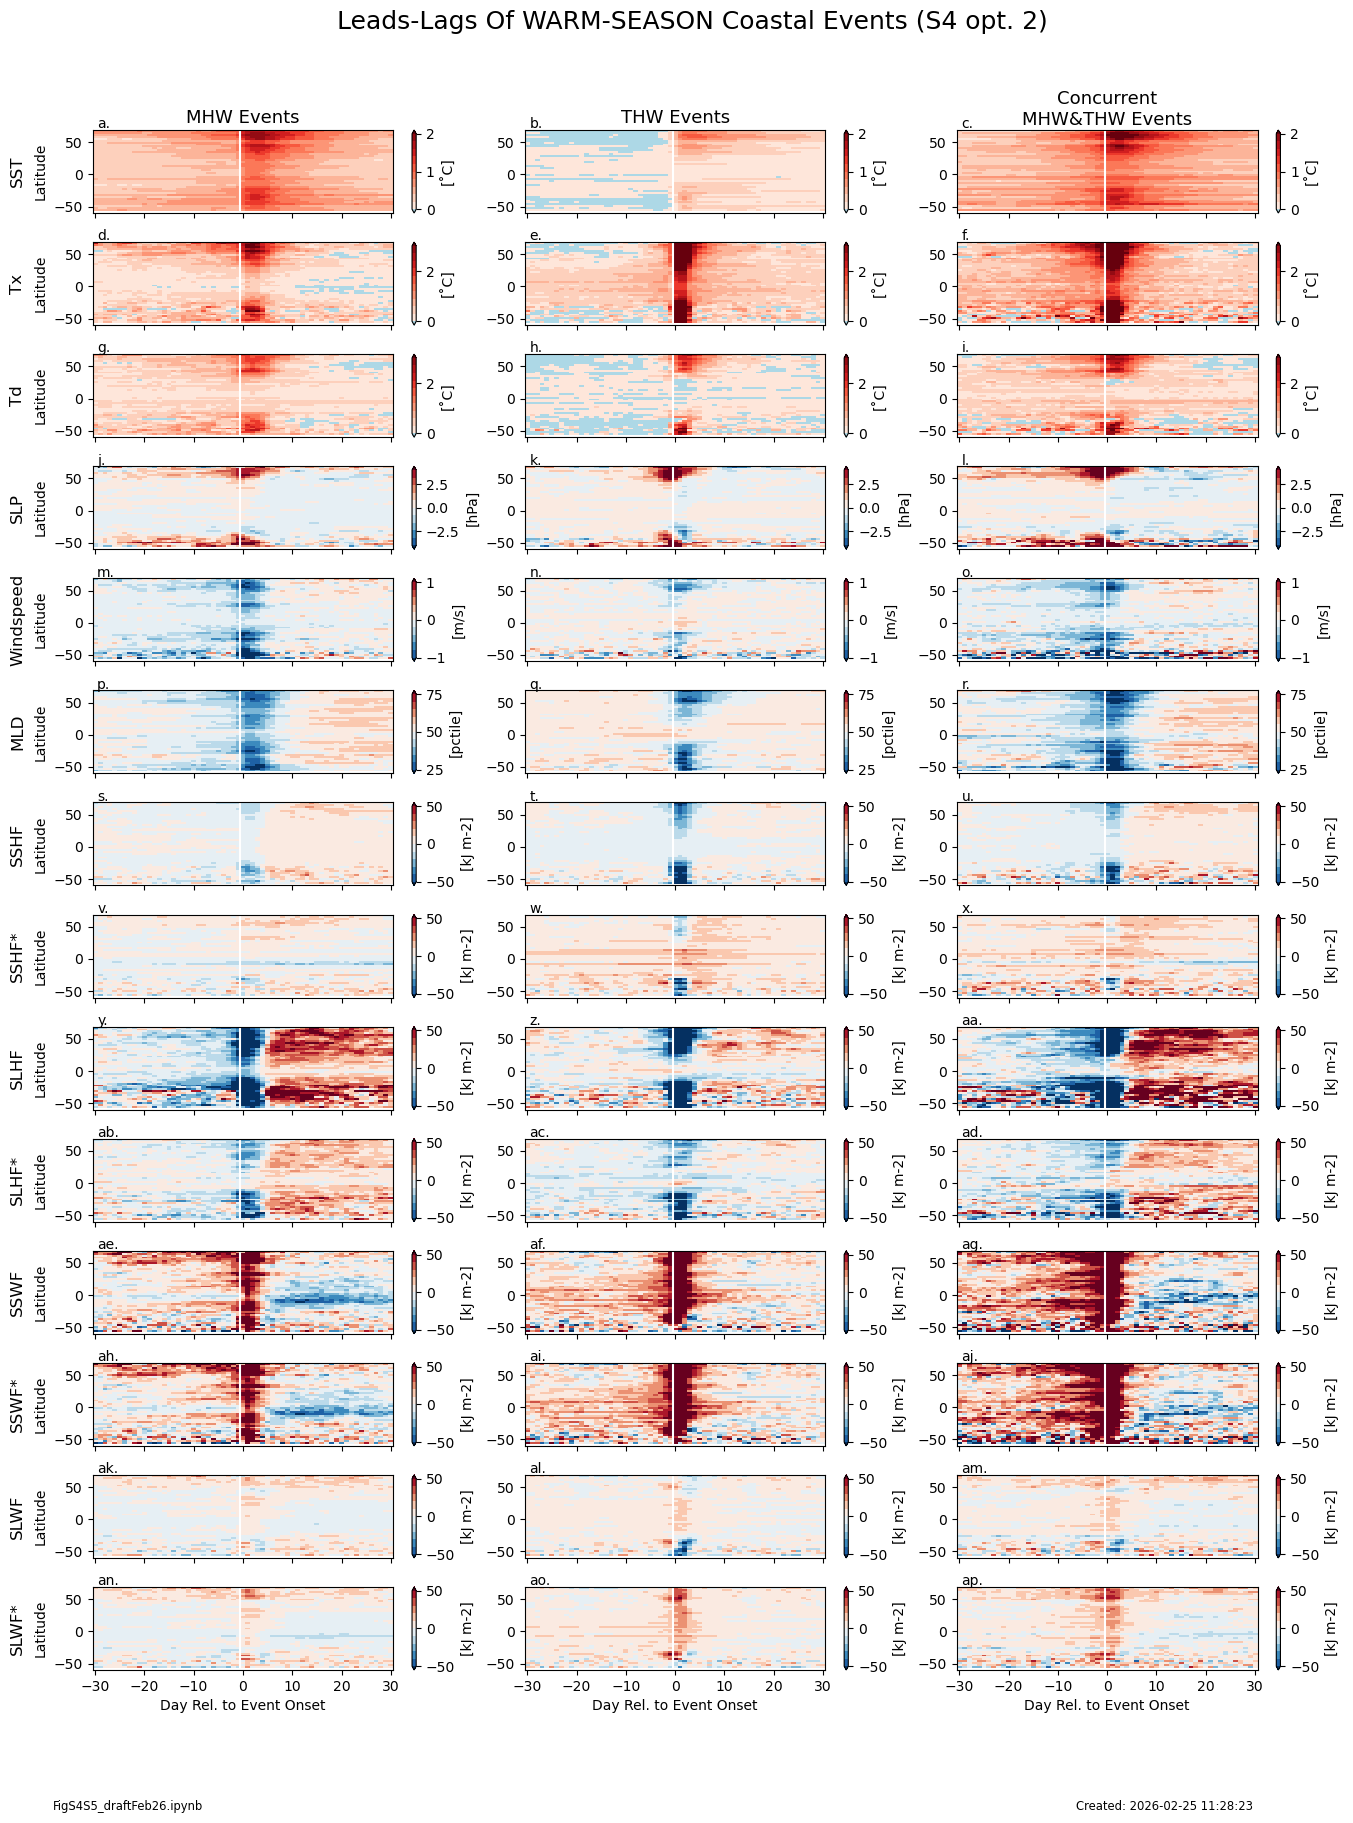

In [32]:
## WARM SEASON LEAD-LAGS with over station as well (S3 - option 2)

# set up figure
nrows = 14
ncols = 3
fig = plt.figure(figsize=(16, 20))
gs = gridspec.GridSpec(nrows=nrows, ncols=ncols, figure=fig) 
gs.update(wspace=0.15, hspace=0.35)


to_plot_list = [[sst_binlag_MHW_w, sst_binlag_THW_w, sst_binlag_con_w],
                [tx_binlag_MHW_w , tx_binlag_THW_w, tx_binlag_con_w],
                [td_binlag_MHW_w, td_binlag_THW_w, td_binlag_con_w],
                [slp_binlag_MHW_w, slp_binlag_THW_w, slp_binlag_con_w],
                [windspeeds_binlag_MHW_w, windspeeds_binlag_THW_w, windspeeds_binlag_con_w], 
                [MLDPctile_binlag_MHW_w, MLDPctile_binlag_THW_w, MLDPctile_binlag_con_w],
                [sshf_binlag_MHW_w, sshf_binlag_THW_w, sshf_binlag_con_w],
                [sshfSTA_binlag_MHW_w, sshfSTA_binlag_THW_w, sshfSTA_binlag_con_w], 
                [slhf_binlag_MHW_w, slhf_binlag_THW_w, slhf_binlag_con_w],
                [slhfSTA_binlag_MHW_w, slhfSTA_binlag_THW_w, slhfSTA_binlag_con_w],
                [ssr_binlag_MHW_w, ssr_binlag_THW_w, ssr_binlag_con_w],
                [ssrSTA_binlag_MHW_w, ssrSTA_binlag_THW_w, ssrSTA_binlag_con_w],
                [str_binlag_MHW_w, str_binlag_THW_w, str_binlag_con_w],
                [strSTA_binlag_MHW_w, strSTA_binlag_THW_w, strSTA_binlag_con_w]]

cmap_list = [cmap_s, cmap_tx, cmap_tx, cmap_sl, cmap_w, cmap_mld, cmap_hf, cmap_hf, cmap_hf, cmap_hf, cmap_hf, cmap_hf, cmap_hf, cmap_hf]
norm_list = [norm_s, norm_tx, norm_tx, norm_sl, norm_w, norm_mld, norm_hf, norm_hf, norm_hf, norm_hf, norm_hf, norm_hf, norm_hf, norm_hf]
bounds_list = [bounds_s, bounds_tx, bounds_tx, bounds_sl, bounds_w, bounds_mld, bounds_hf, bounds_hf, bounds_hf, bounds_hf, bounds_hf, bounds_hf, bounds_hf, bounds_hf]
cmap_label_list = ['[˚C]', '[˚C]', '[˚C]', '[hPa]', '[m/s]', '[pctile]', '[kJ m-2]', '[kJ m-2]', '[kJ m-2]', '[kJ m-2]', '[kJ m-2]', '[kJ m-2]', '[kJ m-2]', '[kJ m-2]']
row_label_list = ['SST', 'Tx', 'Td', 'SLP', 'Windspeed', 'MLD', 'SSHF', 'SSHF*', 'SLHF', 'SLHF*', 'SSWF', 'SSWF*', 'SLWF', 'SLWF*']

axes = []

pltctr = 0
for r in range(nrows):
    for c in range(ncols):
        
        ax = fig.add_subplot(gs[r, c])

        
        data2plot = to_plot_list[r][c]
        data2plot.plot(ax=ax, cmap=cmap_list[r], norm=norm_list[r], cbar_kwargs={'label':cmap_label_list[r], 'extend':'both'})
        
        ax.axvline(-0.5, color='white')
        ax.set(title='', xlabel='', ylabel='')
        
        if not r==(nrows-1):
            ax.set_xticks([-30., -20., -10.,   0.,  10.,  20.,  30.], labels='')
        else:
            ax.set_xticks([-30., -20., -10.,   0.,  10.,  20.,  30.])
            ax.set(xlabel='Day Rel. to Event Onset')
            
        if c==0:
            ax.set(ylabel='Latitude')
            
        ax.text(s='{}.'.format(letters_list[pltctr]), x=0.015, y=1.02, transform=ax.transAxes, ha='left', fontsize=10)
            
        axes.append(ax)
        pltctr+=1 
            
# subplot labels
axes[0].text(x=0.5, y=1.15, s='MHW Events', va='center', ha='center', fontsize='13',
    transform=axes[0].transAxes)

axes[1].text(x=0.5, y=1.15, s='THW Events', va='center', ha='center', fontsize='13',
    transform=axes[1].transAxes)

axes[2].text(x=0.5, y=1.25, s='Concurrent\nMHW&THW Events', va='center', ha='center', fontsize='13',
    transform=axes[2].transAxes)

# y labels
for r in range(nrows):
    aa = axes[0+(r*3)]
    aa.text(x=-0.25, y=0.50, s=row_label_list[r], va='center', ha='center',
        rotation='vertical', rotation_mode='anchor', fontsize='12',
        transform=aa.transAxes)
    
    
plt.suptitle('Leads-Lags Of WARM-SEASON Coastal Events (S4 opt. 2)', fontsize=18, y=0.94)

# timestamp + script
now = datetime.now() # get datetime
fig.text(0.85, 0.04, 'Created: %s' %now.strftime("%Y-%m-%d %H:%M:%S"), fontsize='small', ha='right') # text
fig.text(0.1, 0.04, script, ha='left', fontsize='small')

plt.show()

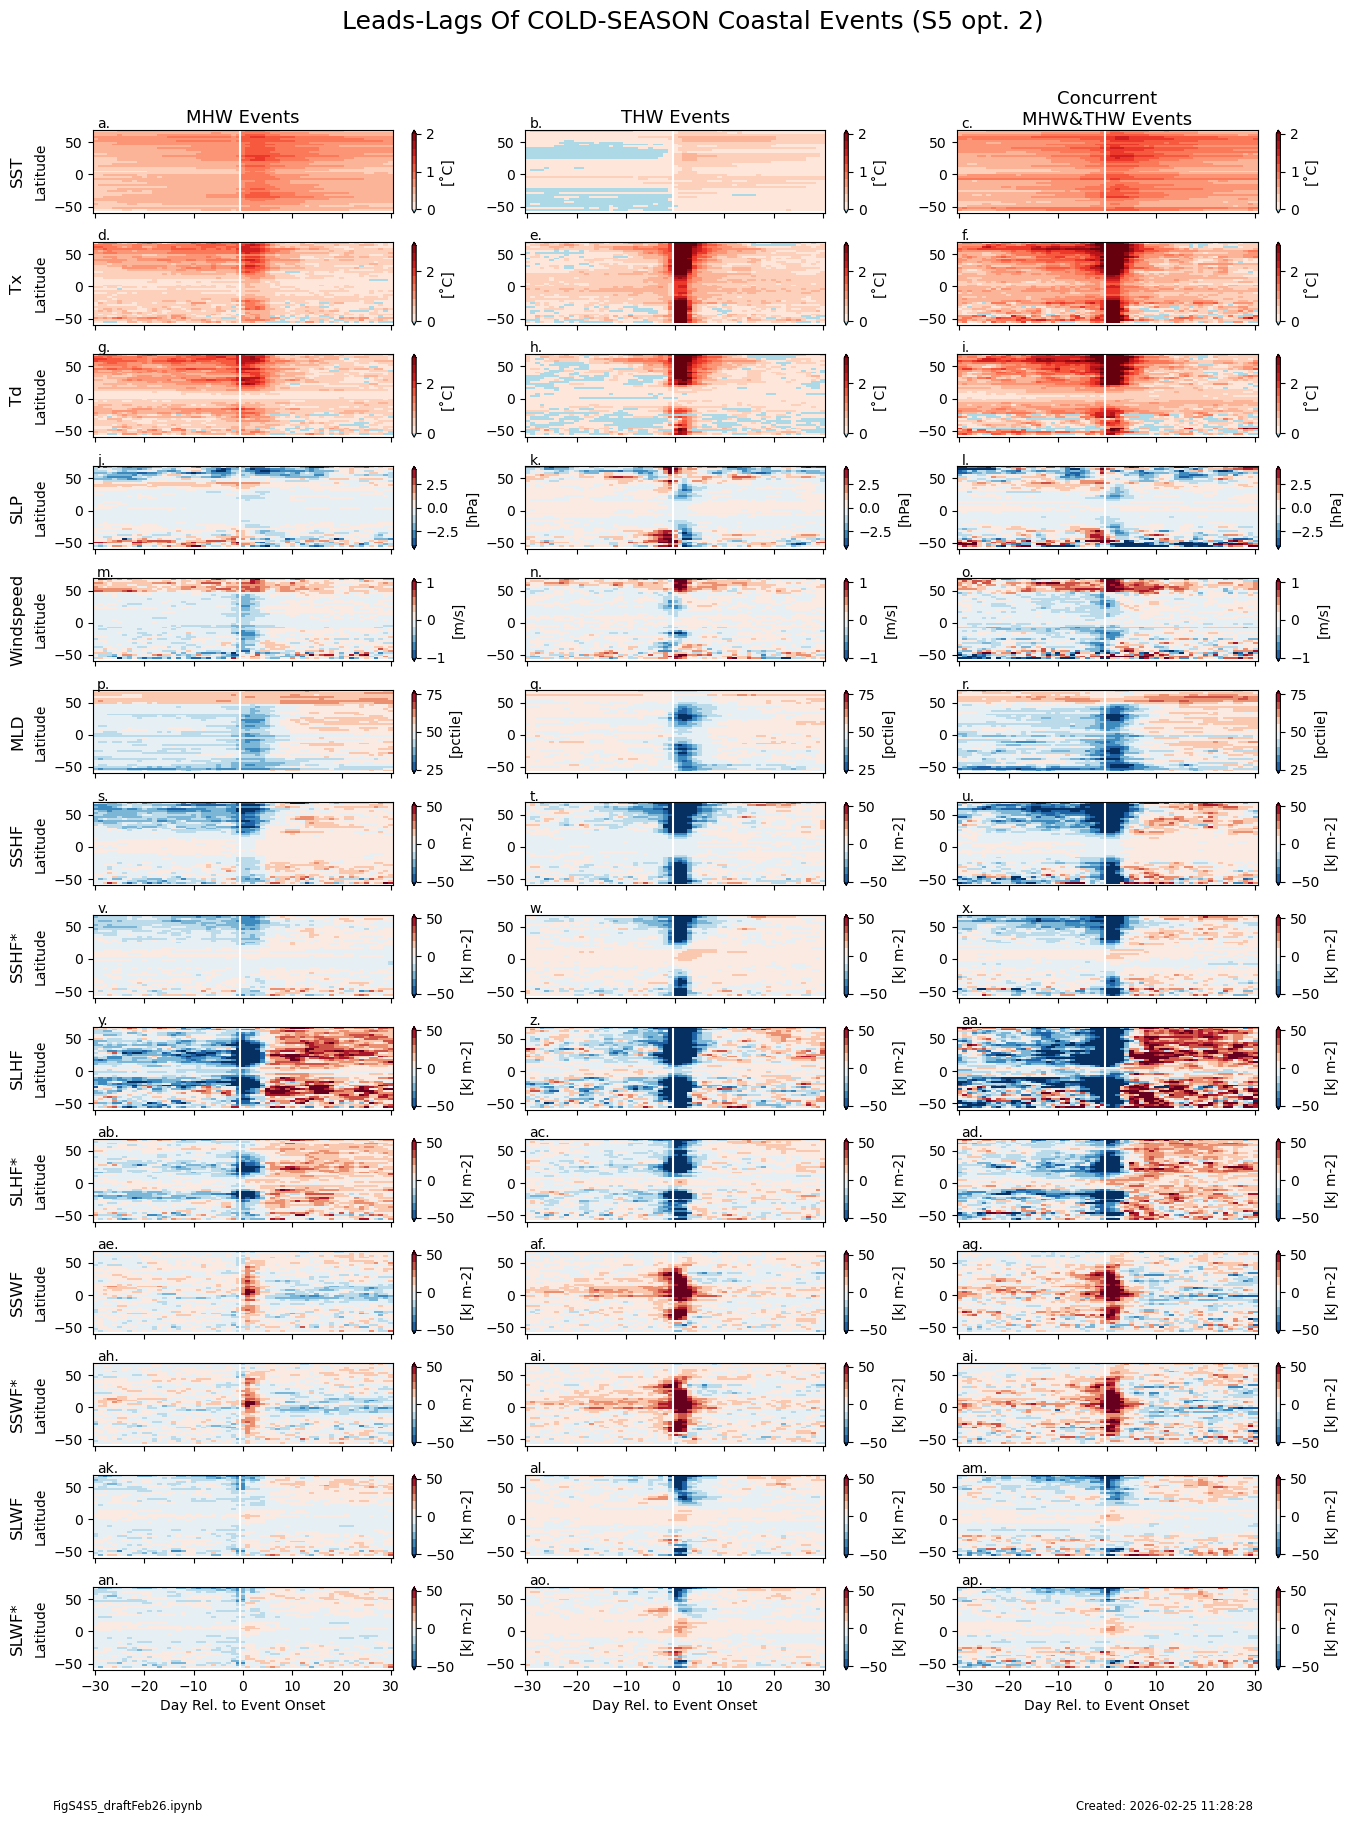

In [33]:
## COLD SEASON LEAD-LAGS with over station as well (S5 - option 2)

# set up figure
nrows = 14
ncols = 3
fig = plt.figure(figsize=(16, 20))
gs = gridspec.GridSpec(nrows=nrows, ncols=ncols, figure=fig) 
gs.update(wspace=0.15, hspace=0.35)


to_plot_list = [[sst_binlag_MHW_c, sst_binlag_THW_c, sst_binlag_con_c],
                [tx_binlag_MHW_c , tx_binlag_THW_c, tx_binlag_con_c],
                [td_binlag_MHW_c, td_binlag_THW_c, td_binlag_con_c],
                [slp_binlag_MHW_c, slp_binlag_THW_c, slp_binlag_con_c],
                [windspeeds_binlag_MHW_c, windspeeds_binlag_THW_c, windspeeds_binlag_con_c], 
                [MLDPctile_binlag_MHW_c, MLDPctile_binlag_THW_c, MLDPctile_binlag_con_c],
                [sshf_binlag_MHW_c, sshf_binlag_THW_c, sshf_binlag_con_c],
                [sshfSTA_binlag_MHW_c, sshfSTA_binlag_THW_c, sshfSTA_binlag_con_c], 
                [slhf_binlag_MHW_c, slhf_binlag_THW_c, slhf_binlag_con_c],
                [slhfSTA_binlag_MHW_c, slhfSTA_binlag_THW_c, slhfSTA_binlag_con_c],
                [ssr_binlag_MHW_c, ssr_binlag_THW_c, ssr_binlag_con_c],
                [ssrSTA_binlag_MHW_c, ssrSTA_binlag_THW_c, ssrSTA_binlag_con_c],
                [str_binlag_MHW_c, str_binlag_THW_c, str_binlag_con_c],
                [strSTA_binlag_MHW_c, strSTA_binlag_THW_c, strSTA_binlag_con_c]]

cmap_list = [cmap_s, cmap_tx, cmap_tx, cmap_sl, cmap_w, cmap_mld, cmap_hf, cmap_hf, cmap_hf, cmap_hf, cmap_hf, cmap_hf, cmap_hf, cmap_hf]
norm_list = [norm_s, norm_tx, norm_tx, norm_sl, norm_w, norm_mld, norm_hf, norm_hf, norm_hf, norm_hf, norm_hf, norm_hf, norm_hf, norm_hf]
bounds_list = [bounds_s, bounds_tx, bounds_tx, bounds_sl, bounds_w, bounds_mld, bounds_hf, bounds_hf, bounds_hf, bounds_hf, bounds_hf, bounds_hf, bounds_hf, bounds_hf]
cmap_label_list = ['[˚C]', '[˚C]', '[˚C]', '[hPa]', '[m/s]', '[pctile]', '[kJ m-2]', '[kJ m-2]', '[kJ m-2]', '[kJ m-2]', '[kJ m-2]', '[kJ m-2]', '[kJ m-2]', '[kJ m-2]']
row_label_list = ['SST', 'Tx', 'Td', 'SLP', 'Windspeed', 'MLD', 'SSHF', 'SSHF*', 'SLHF', 'SLHF*', 'SSWF', 'SSWF*', 'SLWF', 'SLWF*']

axes = []

pltctr = 0
for r in range(nrows):
    for c in range(ncols):
        
        ax = fig.add_subplot(gs[r, c])

        
        data2plot = to_plot_list[r][c]
        data2plot.plot(ax=ax, cmap=cmap_list[r], norm=norm_list[r], cbar_kwargs={'label':cmap_label_list[r], 'extend':'both'})
        
        ax.axvline(-0.5, color='white')
        ax.set(title='', xlabel='', ylabel='')
        
        if not r==(nrows-1):
            ax.set_xticks([-30., -20., -10.,   0.,  10.,  20.,  30.], labels='')
        else:
            ax.set_xticks([-30., -20., -10.,   0.,  10.,  20.,  30.])
            ax.set(xlabel='Day Rel. to Event Onset')
            
        if c==0:
            ax.set(ylabel='Latitude')
            
        ax.text(s='{}.'.format(letters_list[pltctr]), x=0.015, y=1.02, transform=ax.transAxes, ha='left', fontsize=10)

        axes.append(ax)
        pltctr+=1 
    
# subplot labels
axes[0].text(x=0.5, y=1.15, s='MHW Events', va='center', ha='center', fontsize='13',
    transform=axes[0].transAxes)

axes[1].text(x=0.5, y=1.15, s='THW Events', va='center', ha='center', fontsize='13',
    transform=axes[1].transAxes)

axes[2].text(x=0.5, y=1.25, s='Concurrent\nMHW&THW Events', va='center', ha='center', fontsize='13',
    transform=axes[2].transAxes)

# y labels
for r in range(nrows):
    aa = axes[0+(r*3)]
    aa.text(x=-0.25, y=0.50, s=row_label_list[r], va='center', ha='center',
        rotation='vertical', rotation_mode='anchor', fontsize='12',
        transform=aa.transAxes)
    
    
plt.suptitle('Leads-Lags Of COLD-SEASON Coastal Events (S5 opt. 2)', fontsize=18, y=0.94)

# timestamp + script
now = datetime.now() # get datetime
fig.text(0.85, 0.04, 'Created: %s' %now.strftime("%Y-%m-%d %H:%M:%S"), fontsize='small', ha='right') # text
fig.text(0.1, 0.04, script, ha='left', fontsize='small')

plt.show()